In [1]:
#載入套件
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [114]:
#使用資料夾內鐵達尼號的資料集，練習邏輯迴歸的處理邏輯
train = pd.read_csv('data/titanic_data.csv')
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


### 📊 什麼是熱力圖（Heatmap）？

熱力圖是**「把數字表格變成顏色圖」**的工具，透過**顏色的深淺**讓人一眼看出數據重點。

#### 💡 三大核心用途：
1. **揪出缺失值**：把漏掉的資料標成亮色（如黃線），一眼看出哪個欄位缺最兇。
2. **看欄位關係**：分析欄位間的相關性（如票價與艙等），顏色越極端代表關係越貼近。
3. **抓行為熱區**：顯示數據密度的集中地（如網頁滑鼠點擊區、球員投籃熱區）。

### 📊 `sns.heatmap()` 常用參數快速查表

`sns.heatmap()` 是 Seaborn 套件中用來繪製熱力圖（Heatmap）的核心函數，常用參數功能如下：


| 參數名稱 | 資料型態 / 選項 | 功能說明 | 繪製缺失值時的建議值 |
| :--- | :--- | :--- | :--- |
| **`data`** | 2D 矩陣 / DataFrame | 必填。要繪製的二維資料。 | `df.isnull()` |
| **`cmap`** | 字串 (如 `'viridis'`, `'magma'`, `'Blues'`) | 設定熱力圖的**顏色主題**。 | `'viridis'` (黃紫配色) |
| **`cbar`** | 布林值 (`True` / `False`) | 是否顯示右側的**顏色條（Colorbar）**。 | `False` (讓畫面更乾淨) |
| **`yticklabels`**| 布林值 / 列表 | 是否顯示**縱軸（Y軸）標籤**。設定 `False` 可隱藏標籤。 | `False` (避免資料量大時黑成一片) |
| **`xticklabels`**| 布林值 / 列表 | 是否顯示**橫軸（X軸）標籤**。 | `True` (需顯示欄位名稱) |
| **`annot`** | 布林值 (`True` / `False`) | 是否在每個格子內**顯示數值**。 | `False` (缺失值熱力圖不需開啟) |
| **`fmt`** | 字串 (如 `'.1f'`, `'.2g'`, `'d'`) | 設定 `annot` 數值的**顯示格式**（如小數點位數、整數）。 | 無 |
| **`linewidths`**| 數字 | 每個格子之間的**線條寬度**（間隔）。 | 無 |
| **`linecolor`** | 顏色字串 (如 `'white'`, `'black'`) | 格子間隔線條的**顏色**。 | 無 |
| **`vmin` / `vmax`**| 數字 | 手動設定顏色條的**最小值與最大值**。 | 無 |

---


<Axes: >

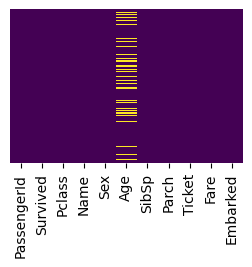

In [9]:
#探索資料
#用heatmap(.isnull()來找出缺失的資料在哪些欄位。Age似乎約有五分之一的資料缺失，可用合理資料補充。)
plt.figure(figsize=(3, 2))
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap="viridis")

### 📊 什麼是計數圖（Countplot）？

`countplot` 是 Seaborn 套件中用來觀察**類別資料（Categorical Data）**分配狀態的長條圖。它的核心功能是**「自動幫數據算總數，並畫成圖」**。

#### 💡 核心用途與特徵：
1. **自動計算次數**：您不需要先用 `value_counts()` 算數量，只要指定欄位（如 `x="Survived"`），它就會自動統計各個分類有多少筆資料。
2. **交叉分析特徵**：透過 `hue` 參數（如 `hue="Sex"`），可以將同一個類別內再拆解出另一個特徵的比例，用來觀察兩個變數之間的關聯（例如：不同性別的存活人數消長）。
3. **直觀呈現比例差別**：特別適合用來快速驗證假設（如：女性存活人數是否真的比男性高）。

### ⚙️ `sns.countplot()` 常用參數快速查表

`sns.countplot()` 主要用來統計類別變數的數量，常用參數功能如下：


| 參數名稱 | 資料型態 / 選項 | 功能說明 | 範例參考 |
| :--- | :--- | :--- | :--- |
| **`x`** | 字串（欄位名稱） | 設定**橫軸**要統計的類別欄位（直立長條圖）。 | `x="Survived"` |
| **`y`** | 字串（欄位名稱） | 設定**縱軸**要統計的類別欄位（水平長條圖）。 | `y="Pclass"` |
| **`hue`** | 字串（欄位名稱） | 設定**分組欄位**，在同一個類別內再用顏色分組。 | `hue="Sex"` |
| **`data`** | DataFrame | 必填。指定要讀取的 **Pandas DataFrame**。 | `data=df` |
| **`palette`** | 字串（色調名稱） | 設定長條圖的**顏色主題**（如 `Pastel1`, `Set2`, `viridis`）。| `palette="Pastel1"` |
| **`color`** | 顏色字串 | 當不用 `hue` 區分顏色時，設定**所有長條的單一顏色**。| `color="skyblue"` |
| **`order`** | 列表 (List) | 手動設定橫軸類別呈現的**先後順序**。 | `order=[1, 2, 3]` |
| **`hue_order`**| 列表 (List) | 手動設定分組顏色在圖例（Legend）中的**先後順序**。 | `hue_order=['female', 'male']` |

---

💡 **快速提醒：** `x` 和 `y` 通常只會二選一填入。填 `x` 畫出來是直的長條圖，填 `y` 畫出來是橫的長條圖。

<Axes: xlabel='Survived', ylabel='count'>

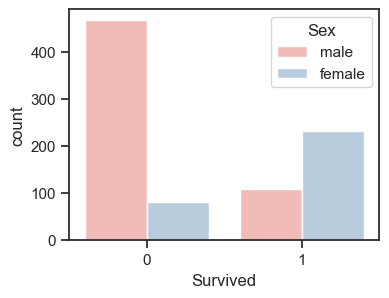

In [20]:
#用countplot來看性別是否影響最後存活。女性存活比例比男性高。
plt.figure(figsize=(4, 3))
sns.set_theme(style="ticks", palette="Pastel1")
sns.countplot(x="Survived", hue="Sex", data=train)

<Axes: xlabel='Survived', ylabel='count'>

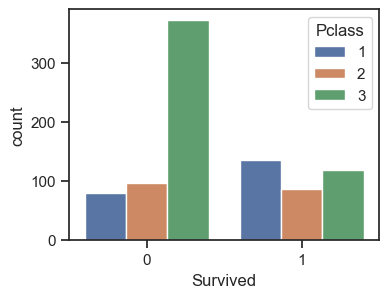

In [30]:
#艙等是否也影響存活?
plt.figure(figsize=(4, 3))
sns.countplot(x="Survived", hue="Pclass", data=train, palette="deep")

markdown### 📊 什麼是直方圖（Histplot）？

`histplot` 是 Seaborn 套件中用來觀察**連續型數值（Continuous Data）**分佈狀態的圖表。它透過將資料切分成數個連續區間（Bins），統計每個區間內的資料數量（次數）。

#### 💡 核心用途與特徵：
1. **掌握數據形狀**：一眼看出數據的集中趨勢。例如鐵達尼號的乘客主要集中在 20 至 30 歲的年輕人。
2. **找出極端值與異常點**：容易發現是否有極端高齡（如 80 歲）或極端低齡（如嬰幼兒）的特殊數據分佈。
3. **檢查資料偏態（Skewness）**：觀察圖表是偏向左側、右側，還是呈現對稱的鐘形（常態分佈），這對機器學習模型的特徵工程（如是否需要做對數轉換）非常關鍵。

### ⚙️ `sns.histplot()` 常用參數快速查表

`sns.histplot()` 主要用來統計連續型變數的分佈，常用參數功能如下：


| 參數名稱 | 資料型態 / 選項 | 功能說明 | 範例參考 |
| :--- | :--- | :--- | :--- |
| **`data`** | DataFrame / 陣列 | 必填。指定要讀取的 **Pandas DataFrame** 或資料陣列。 | `data=df` |
| **`x` / `y`** | 字串（欄位名稱） | 指定要分配的數值欄位。填 `x` 為直立直方圖，填 `y` 為水平直方圖。 | `x="Age"` |
| **`bins`** | 數字 / 列表 / 字串 | 設定**區間（格子）的數量**。數字越大格子越細，預設為自動計算。 | `bins=30` |
| **`binwidth`** | 數字 | 手動固定**每個區間的寬度**（例如每 5 歲切一格），與 `bins` 二選一。| `binwidth=5` |
| **`kde`** | 布林值 (`True` / `False`) | 是否平滑地疊加**核密度估計曲線（KDE）**，用來觀察流線形分佈。| `kde=True` |
| **`hue`** | 字串（欄位名稱） | 設定**分組欄位**，在同一個分佈內用不同顏色觀察類別差異。| `hue="Survived"` |
| **`multiple`** | `'layer'`/`'dodge'`/`'stack'` | 當有 `hue` 分組時，設定長條的**堆疊或排列方式**（重疊、並排或堆疊）。| `multiple="stack"` |
| **`element`** | `'bars'`/`'step'`/`'poly'` | 設定圖表的外觀。`'step'` 會只畫出輪廓線，不填滿顏色。| `element="bars"` |
| **`linewidth`** | 數字 | 設定每個長條之間的**邊框線條寬度**。設為 `0` 可讓圖表完全連續。| `linewidth=0` |
| **`edgecolor`** | 顏色字串 / `'none'` | 設定格子邊框的**顏色**。設為 `'none'` 可移除邊框線。 | `edgecolor="none"` |
| **`alpha`** | 數字 (0.0 ~ 1.0) | 設定長條圖的**透明度**。數值越低顏色越淡、越透明。 | `alpha=0.4` |

---

💡 **快速提醒：** 在處理像是 `Age` 或 `Fare` 這類有缺失值的欄位時，記得先使用 `.dropna()` 排除缺失值，圖表才能正確繪製喔！

<Axes: xlabel='Age', ylabel='Count'>

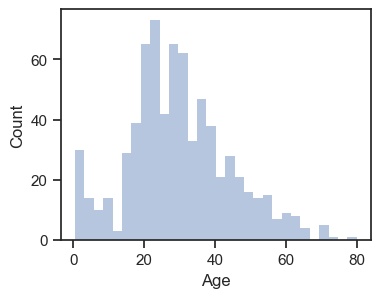

In [43]:
#用直方圖看年齡分佈。缺失資料在此不計。
plt.figure(figsize=(4, 3))
sns.histplot(train["Age"].dropna(), bins=30, linewidth=0, alpha=0.4)

C:\Users\User\AppData\Local\Temp\ipykernel_17836\2526748526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="SibSp" , data=train, palette="deep")


<Axes: xlabel='SibSp', ylabel='count'>

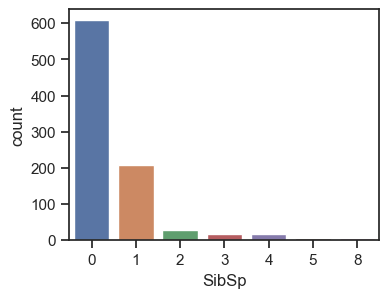

In [47]:
#SibSp代表兄弟姐妹或眷屬人數
plt.figure(figsize=(4, 3))
sns.countplot(x="SibSp" , data=train, palette="deep")

<Axes: xlabel='Fare', ylabel='Count'>

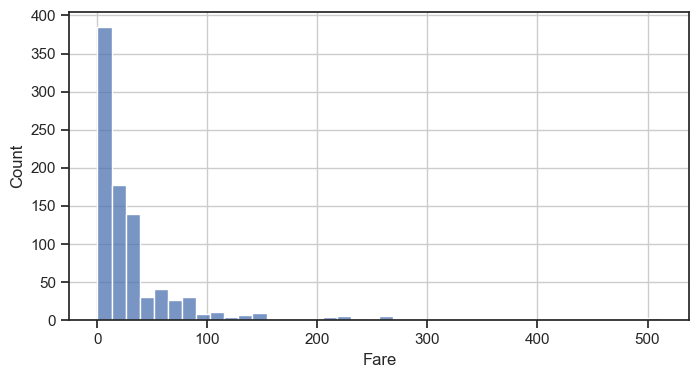

In [56]:
#用直方圖看票價分佈
plt.figure(figsize=(8, 4))
plt.grid(True)
sns.histplot(train["Fare"].dropna(), bins=40, edgecolor="white")

### 📊 什麼是盒鬚圖（Boxplot）？

`boxplot` 是一種用來呈現**連續型數值（Continuous Data）**在不同**類別（Categorical Data）**下，五數總括（最小值、第一四分位數、中位數、第三四分位數、最大值）統計分佈的圖表。

#### 💡 核心用途與特徵：
1. **掌握集中與離散趨勢**：盒子中央的橫線是**中位數**，盒子的長短代表資料的集中或分散程度。例如您可以一眼看出 1 等艙的年齡中位數明顯高於 3 等艙。
2. **一眼揪出極端異常值**：在上下兩端「鬍鬚」之外的獨立孤立點（通常用小圓點或菱形表示），代表統計學上的**異常值（Outliers）**。
3. **輔助精準缺失值補齊**：當發現連續變數與某個類別變數有明顯分佈階層（如：艙等越高、年齡越大）時，就能放棄使用整體平均數，改用「各組中位數」來更精準地填補缺失資料。

### ⚙️ `sns.boxplot()` 常用參數快速查表

`sns.boxplot()` 主要用來統計連續型變數在不同類別下的分佈與異常值，常用參數功能如下：



| 參數名稱 | 資料型態 / 選項 | 功能說明 | 範例參考 |
| :--- | :--- | :--- | :--- |
| **`data`** | DataFrame | 必填。指定要讀取的 **Pandas DataFrame**。 | `data=df` |
| **`x`** | 字串（欄位名稱） | 設定**橫軸**變數。通常放類別欄位（畫出直立盒鬚圖）。 | `x="Pclass"` |
| **`y`** | 字串（欄位名稱） | 設定**縱軸**變數。通常放連續數值欄位。 | `y="Age"` |
| **`hue`** | 字串（欄位名稱） | 設定**進階分組欄位**，在原本的箱子旁再拆出子分組。 | `hue="Survived"` |
| **`palette`** | 字串（色調名稱） | 設定每個箱子的**顏色主題**（如 `deep`, `Set2`, `Pastel1`）。 | `palette="deep"` |
| **`width`** | 數字 (0.0 ~ 1.0) | 設定**箱子的寬度**。數值越小箱子越瘦，預設為 0.8。 | `width=0.5` |
| **`fliersize`** | 數字 | 設定**異常值（外顯圓點）的大小**。設為 0 可以隱藏異常值。| `fliersize=5` |
| **`linewidth`** | 數字 | 設定箱子線條、中位數線與鬍鬚的**線條粗細**。 | `linewidth=1.5` |
| **`orient`** | `'v'` / `'h'` | 設定圖表**方向**。`'v'` 為直立（預設），`'h'` 為水平。 | `orient="v"` |
| **`notch`** | 布林值 (`True` / `False`) | 是否在箱子中位數處**挖出凹槽**，用來強調中位數的置信區間。| `notch=True` |

---

💡 **進階技巧：** 如果想把圖表橫著畫，只要把 `x` 和 `y` 的欄位對調（`x="Age"`, `y="Pclass"`），或是加上 `orient="h"` 就可以囉！

C:\Users\User\AppData\Local\Temp\ipykernel_17836\2095483815.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Age", data=train, palette="deep")


<Axes: xlabel='Pclass', ylabel='Age'>

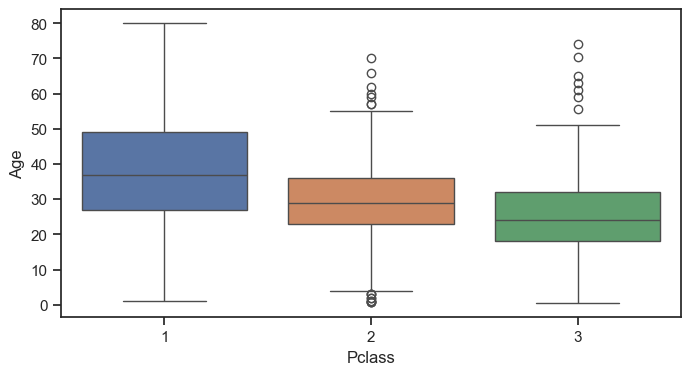

In [58]:
#資料清理
#剛有看到年齡資料約有五分之一缺失，一種做法是棄之不用，一種可以考慮把年齡平均放進去。
#使用盒鬚圖來看年齡和艙等的分佈。看起來頭等艙年齡較高，隨之降低。
plt.figure(figsize=(8, 4))
sns.boxplot(x="Pclass", y="Age", data=train, palette="deep")

In [124]:
#把艙等平均年齡填入缺失的資料中.
#艙等1平均年齡是37，艙等2平均年齡是29，艙等3平均年齡是24
train["Age"] = train["Age"].fillna(
  train.groupby("Pclass")["Age"].transform("mean")
).astype(int)

<Axes: >

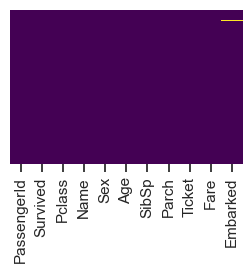

In [65]:
#用heatmap查看年齡是否還有缺失資料
plt.figure(figsize=(3, 2))
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap="viridis")

In [66]:
train.dropna(inplace=True)#inplace： False: 返回新的數據集（默認） True: 在原數據集上操作

In [69]:
#虛擬變數範例
#使用pandas(d.get_dummies)將性別從類別資料轉為數值變數。
sex_encoded = pd.get_dummies(train["Sex"], drop_first=True, dtype=int)
#請將drop_first=True，如果為True會刪除第一個類別值。
#本來若有k個level，drop_first=True會只剩下k-1個level，降低共線性的可能
sex_encoded.head()

,male
0,1
1,0
2,0
3,0
4,1


In [72]:
#使用pandas將上船的港口從類別資料改換為數值變數(drop_first=True)
embarked_encoded = pd.get_dummies(train["Embarked"], drop_first=True, dtype=int)
embarked_encoded.head()

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1


In [115]:
#將性別及上船港口的數值變數和原始的data結合
train = pd.concat([train,sex_encoded,embarked_encoded], axis=1)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1.0,0.0,1.0


In [116]:
#將原始的性別、登船港口、票號、姓名欄位棄用
train.drop(["Name", "Sex", "Ticket"], axis=1, inplace=True)
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,male,Q,S
0,1,0,3,22.0,1,0,7.2500,S,1.0,0.0,1.0
1,2,1,1,38.0,1,0,71.2833,C,0.0,0.0,0.0
2,3,1,3,26.0,0,0,7.9250,S,0.0,0.0,1.0
3,4,1,1,35.0,1,0,53.1000,S,0.0,0.0,1.0
4,5,0,3,35.0,0,0,8.0500,S,1.0,0.0,1.0


In [117]:
#因為PassengerId在此也只是排序，因此也棄用
train.drop("PassengerId", axis=1, inplace=True)
train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,male,Q,S
0,0,3,22.0,1,0,7.2500,S,1.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,C,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,S,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,S,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,S,1.0,0.0,1.0


In [118]:
train.drop(columns=["Embarked"], inplace=True, errors="ignore")

In [119]:
train

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,1.0,0.0,1.0
887,1,1,19.0,0,0,30.0000,0.0,0.0,1.0
888,0,3,NaN,1,2,23.4500,0.0,0.0,1.0
889,1,1,26.0,0,0,30.0000,1.0,0.0,0.0


In [134]:
#建立feature資料集(選取survived以外所有欄位)與target資料集(survived)
X = train.drop("Survived", axis=1)
y = train["Survived"]

In [88]:
#載入訓練組及測試組分組套件
from sklearn.model_selection import train_test_split

In [135]:
#設定隨機種子(random_state)為101，測試組比例佔30%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101, stratify=y
)

In [92]:
#載入邏輯回歸
from sklearn.linear_model import LogisticRegression

In [138]:
print(train.isnull().sum())

Survived    0
Pclass      0
Age         0
SibSp       0
Parch       0
Fare        0
male        0
Q           0
S           0
dtype: int64


In [130]:
train.dropna(subset=["male", "Q","S"], inplace=True)

In [137]:
#建立訓練組邏輯迴歸模型
model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [141]:
#使用模型進行測試集資料的預測
prediction = model.predict(X_test)
predictions2 = model.predict(X_train)

In [142]:
#ground truth
print(y_test.values)
print(y_train.values)

[0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0
 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 1 0 0 0 1 0 1 1 1 0 1 0 0 1 0 0 0 1 1 1 1 0
 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0
 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 0 1 0 1 0 1 0 1 0 1 1 0 0 1 1 0 1 0 0 0 0
 1 0 1 1 1 0 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 1 0 1
 0 0 1 0 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0
 1 1 1 0 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 1 1 0
 0 0 1 0 1 0 1 0]
[1 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 1 1 1 0 1 0 0 1 0 0 1 0 1 1 1 0 1 0 0 0 1
 1 0 0 0 1 1 1 0 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 1 0
 1 0 0 0 1 0 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 1 0 1 0 0 1 0 1
 1 1 0 1 1 1 1 0 0 0 1 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 1
 0 1 0 

#### 計算accuracy及結果顯示
accuracy<br>
error_index #錯誤答案是哪幾筆資料<br>
miss classification #錯誤答案<br>
錯誤欄位的正確之原始資料表格

In [147]:
score01 = model.score(X_train, y_train)
print("train Accuracy :" + str(score01))
score = model.score(X_test, y_test)
print("test Accuracy :" + str(score))

train Accuracy :0.8102893890675241
test Accuracy :0.7940074906367042


In [153]:
predictions = model.predict(X_test)

# 2. 正確比對：用 y_test 的真實答案去比對預測答案 predictions
error_index = np.where(y_test.values != predictions)[0]#錯誤答案

# 3. 印出結果
print("錯誤的索引位置 (error_index) :", error_index)
print("這些位置模型猜錯的答案 (miss classification) :", predictions[error_index])#錯誤答案

錯誤的索引位置 (error_index) : [  7  22  25  28  32  34  38  39  48  56  60  64  68  69  70 116 119 128
 132 135 140 141 149 150 151 152 156 160 166 169 175 187 191 192 195 200
 202 217 219 220 221 223 228 232 234 239 240 244 247 249 255 257 260 264
 265]
這些位置模型猜錯的答案 (miss classification) : [1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0 0 1 1 1 0
 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0 1 1 0]


In [154]:
data_index=train.iloc[error_index].index#這裡變數train是所有資料
train.iloc[data_index]#錯誤欄位的正確之原始資料

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
7,0,3,2,3,1,21.0750,1.0,0.0,1.0
22,1,3,15,0,0,8.0292,0.0,1.0,0.0
25,1,3,38,1,5,31.3875,0.0,0.0,1.0
28,1,3,25,0,0,7.8792,0.0,1.0,0.0
32,1,3,25,0,0,7.7500,0.0,1.0,0.0
34,0,1,28,1,0,82.1708,1.0,0.0,0.0
38,0,3,18,2,0,18.0000,0.0,0.0,1.0
39,1,3,14,1,0,11.2417,0.0,0.0,0.0
48,0,3,25,2,0,21.6792,1.0,0.0,0.0
56,1,2,21,0,0,10.5000,0.0,0.0,1.0
